# PopOut — Decision Tree AI Pipeline

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — find the minimum number of features needed to play well
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each worker plays one **complete game** from the empty board — both sides driven
by **FlatNumbaSolverMCTS** (full Numba JIT loop, 30–60k iter/s).  Every position
visited during the game is recorded as a `(board state, best move)` training pair.

This produces ~25–35 realistic samples per game covering opening, mid-game, and
end-game, and naturally includes the tactical positions where **pop moves** are
optimal — something random scrambling almost never generates.

The solver exits early once a position is **proven**, so most moves cost well
under the 100 000 iteration maximum.

In [15]:
N_GAMES    = 200     # full games to play if regenerating
ITERATIONS = 100_000 # max MCTS iterations per move (exits when proven & all root moves tried)
DATA_PATH  = Path('../data/generated/popout_dt_dataset.csv')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df)} rows ← {DATA_PATH}')
    print('Delete the file and re-run this cell to regenerate.')
else:
    print(f'Playing {N_GAMES} full games, up to {ITERATIONS:,} iterations/move ...')
    print(f'Workers: {os.cpu_count()} cores  |  Engine: FlatNumbaSolverMCTS')
    t0 = time.perf_counter()
    df = generate_dataset_parallel(n_games=N_GAMES, iterations=ITERATIONS, seed=42)
    elapsed = time.perf_counter() - t0
    df.to_csv(DATA_PATH, index=False)
    print(f'Done in {elapsed:.1f} s  |  {len(df)} positions  |  {len(df)/N_GAMES:.1f} moves/game')
    print(f'Saved → {DATA_PATH}')

print(f'\nDataset: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded existing dataset: 7932 rows ← ../data/generated/popout_dt_dataset.csv
Delete the file and re-run this cell to regenerate.

Dataset: 7932 rows × 44 columns


## 2. Data Exploration

In [16]:
TARGET       = 'best_move'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
print()
df.head(3)

Features : 43  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... current_player)
Classes  : 14 unique moves



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,cell_4_6,cell_5_0,cell_5_1,cell_5_2,cell_5_3,cell_5_4,cell_5_5,cell_5_6,current_player,best_move
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,drop_3
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,drop_3
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,drop_3


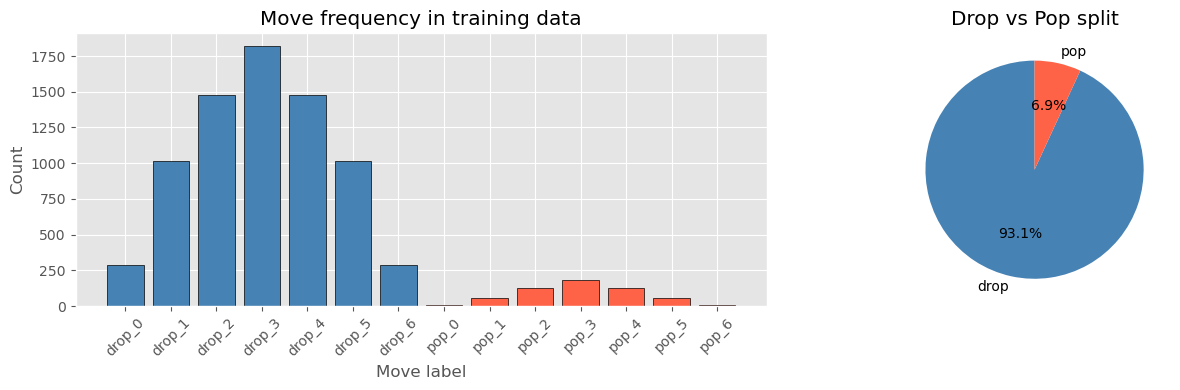

Drop moves: 7386 (93.1%)   Pop moves: 546 (6.9%)


In [17]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

In [18]:
# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# 80 / 20 split (stratified by move label)
df_train = df_str.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df_str.drop(df_train.index).reset_index(drop=True)

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

clf_full = ID3Classifier(max_depth=15)
t0 = time.perf_counter()
clf_full.fit(df_train, target=TARGET)
train_time = time.perf_counter() - t0

train_acc = clf_full.score(df_train, target=TARGET)
test_acc  = clf_full.score(df_test,  target=TARGET)

print(f'Training time : {train_time:.2f} s')
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

Train: 6346  |  Test: 1586
Training time : 19.10 s
Train accuracy: 0.856
Test  accuracy: 0.834


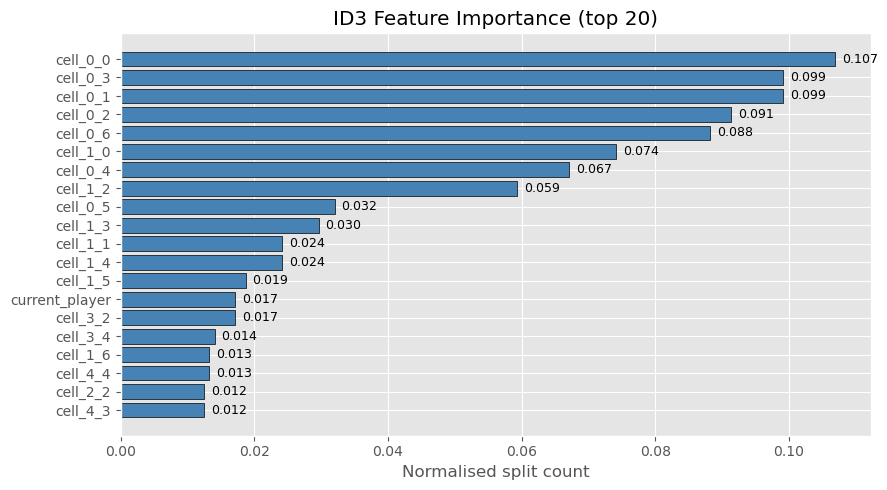

In [19]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the training set, then train
separate ID3 trees using only the top-K features.  The accuracy curve reveals the
**minimum feature budget** the game requires to achieve good move prediction.

In [20]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. cell_3_3            IG = 0.5480
   2. cell_2_3            IG = 0.3760
   3. cell_0_2            IG = 0.3353
   4. cell_0_4            IG = 0.3351
   5. cell_1_4            IG = 0.2500
   6. cell_1_2            IG = 0.2457
   7. cell_1_3            IG = 0.2387
   8. cell_0_5            IG = 0.2290
   9. cell_0_1            IG = 0.2284
  10. cell_2_4            IG = 0.1966


In [21]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.389  test=0.378
K=  3  train=0.409  test=0.400
K=  5  train=0.489  test=0.487
K= 10  train=0.664  test=0.656
K= 15  train=0.724  test=0.722
K= 20  train=0.769  test=0.767
K= 30  train=0.836  test=0.817
K= 43  train=0.856  test=0.834


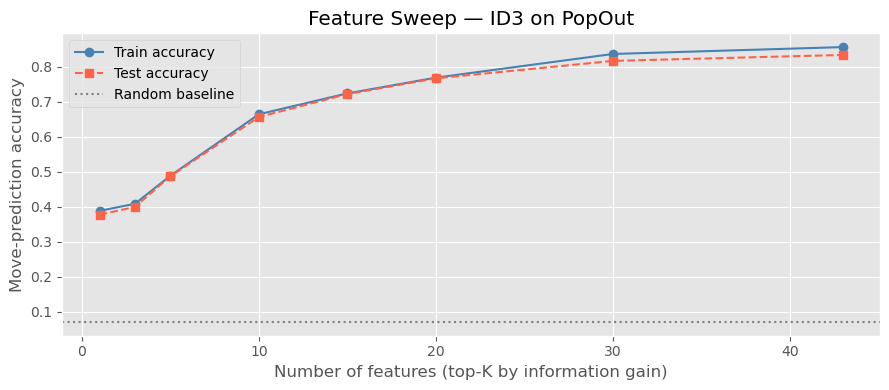

In [22]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Win-Rate Evaluation

The ID3 tree is evaluated against two engine families at multiple iteration counts:

| Engine | Iterations tested | Notes |
|---|---|---|
| **FlatNumbaMCTS** | 100 · 500 · 1 000 · 5 000 · 10 000 | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | 1 000 · 5 000 · 10 000 · 50 000 · 100 000 | MCTS-Solver, exits when proven & all root moves tried |

30 games per configuration, alternating sides for balance.
When the tree predicts an illegal move it falls back to a random legal move.

In [23]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.0 s


In [24]:
def _label_to_move(label: str) -> int:
    move_type, col = label.split('_')
    return int(col) if move_type == 'drop' else int(col) + 7


def tree_choose_move(clf, board):
    features = board.to_feature_dict()
    row  = pd.Series({k: str(v) for k, v in features.items()})
    move = _label_to_move(clf.predict_one(row))
    legal = board.legal_moves()
    return move if move in legal else random.choice(legal)


def play_one_game(clf, agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game; returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        move  = tree_choose_move(clf, board) if mover == tree_plays_as \
                else agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [25]:
EVAL_GAMES = 30

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

eval_results = {}   # (engine, iters) -> (wins, losses, draws)

t0 = time.perf_counter()
for engine_name, iter_list in CONFIGS.items():
    for iters in iter_list:
        agent = (FlatNumbaMCTS(max_nodes=iters + 256)
                 if engine_name == 'FlatNumbaMCTS'
                 else FlatNumbaSolverMCTS(max_nodes=iters + 256))

        wins = losses = draws = 0
        for i in range(EVAL_GAMES):
            r = play_one_game(clf_full, agent, 1 if i % 2 == 0 else 2, iters)
            if r == 1:    wins   += 1
            elif r == -1: losses += 1
            else:         draws  += 1

        eval_results[(engine_name, iters)] = (wins, losses, draws)
        wr = wins / EVAL_GAMES
        print(f'{engine_name:22s}  {iters:7,d} iter  →  {wr:5.1%}  ({wins}W / {losses}L / {draws}D)')

    print()

print(f'Total evaluation time: {time.perf_counter() - t0:.1f} s')

FlatNumbaMCTS               100 iter  →  40.0%  (12W / 18L / 0D)
FlatNumbaMCTS               500 iter  →   3.3%  (1W / 29L / 0D)
FlatNumbaMCTS             1,000 iter  →   3.3%  (1W / 29L / 0D)
FlatNumbaMCTS             5,000 iter  →   0.0%  (0W / 30L / 0D)
FlatNumbaMCTS            10,000 iter  →   0.0%  (0W / 30L / 0D)

FlatNumbaSolverMCTS       1,000 iter  →   0.0%  (0W / 30L / 0D)
FlatNumbaSolverMCTS       5,000 iter  →   6.7%  (2W / 28L / 0D)
FlatNumbaSolverMCTS      10,000 iter  →  16.7%  (5W / 25L / 0D)
FlatNumbaSolverMCTS      50,000 iter  →  46.7%  (14W / 16L / 0D)
FlatNumbaSolverMCTS     100,000 iter  →  46.7%  (14W / 16L / 0D)

Total evaluation time: 98.1 s


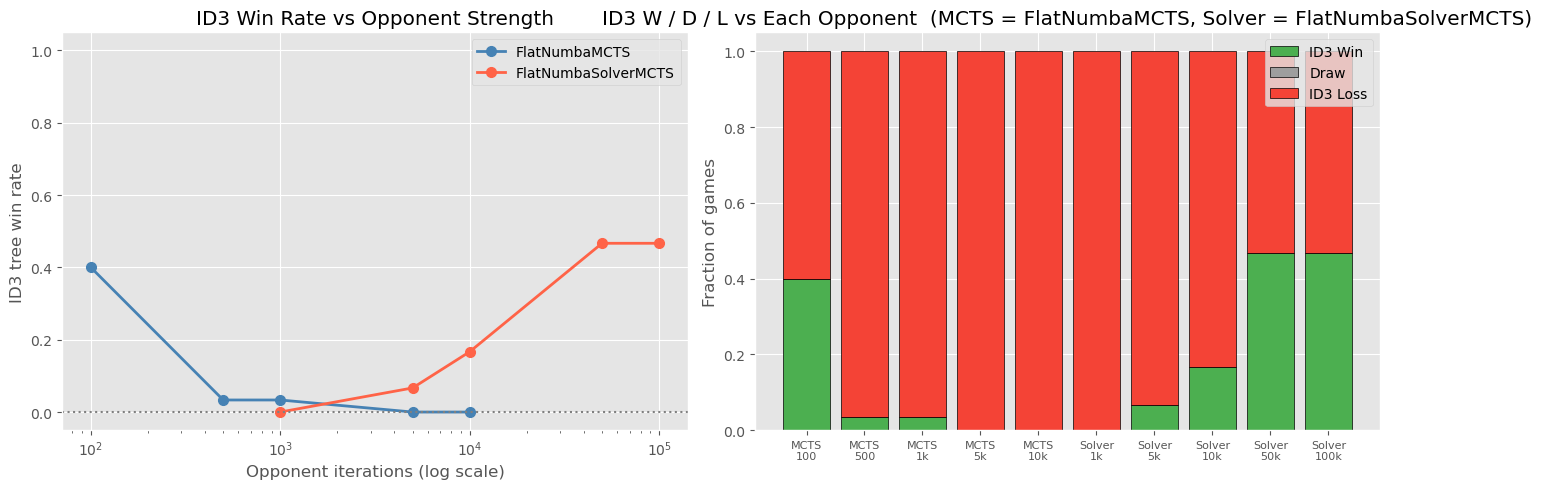


Opponent engine         Iterations   ID3 Win%   ID3 W   ID3 L    Draw
─────────────────────────────────────────────────────────────────
FlatNumbaMCTS                  100      40.0%      12      18       0
FlatNumbaMCTS                  500       3.3%       1      29       0
FlatNumbaMCTS                1,000       3.3%       1      29       0
FlatNumbaMCTS                5,000       0.0%       0      30       0
FlatNumbaMCTS               10,000       0.0%       0      30       0

FlatNumbaSolverMCTS          1,000       0.0%       0      30       0
FlatNumbaSolverMCTS          5,000       6.7%       2      28       0
FlatNumbaSolverMCTS         10,000      16.7%       5      25       0
FlatNumbaSolverMCTS         50,000      46.7%      14      16       0
FlatNumbaSolverMCTS        100,000      46.7%      14      16       0



In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}
colors       = {'FlatNumbaMCTS': 'steelblue', 'FlatNumbaSolverMCTS': 'tomato'}

# Left: ID3 win rate vs opponent iterations, one line per engine family
for engine_name, iter_list in CONFIGS.items():
    win_rates = [eval_results[(engine_name, it)][0] / EVAL_GAMES for it in iter_list]
    axes[0].plot(iter_list, win_rates, 'o-',
                 label=engine_name, color=colors[engine_name], linewidth=2, markersize=7)

axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('ID3 tree win rate')
axes[0].set_title('ID3 Win Rate vs Opponent Strength')
axes[0].set_ylim(-0.05, 1.05)
axes[0].axhline(0, color='gray', linestyle=':')
axes[0].legend()

# Right: stacked W / D / L bar chart (all from ID3's perspective)
bar_labels, bar_w, bar_d, bar_l = [], [], [], []
for engine_name, iter_list in CONFIGS.items():
    short = ENGINE_SHORT[engine_name]
    for it in iter_list:
        w, l, d = eval_results[(engine_name, it)]
        label = f'{short}\n{it//1000}k' if it >= 1000 else f'{short}\n{it}'
        bar_labels.append(label)
        bar_w.append(w / EVAL_GAMES)
        bar_d.append(d / EVAL_GAMES)
        bar_l.append(l / EVAL_GAMES)

x = range(len(bar_labels))
axes[1].bar(x, bar_w, label='ID3 Win',  color='#4CAF50', edgecolor='black')
axes[1].bar(x, bar_d, bottom=bar_w,     label='Draw',     color='#9E9E9E', edgecolor='black')
axes[1].bar(x, bar_l, bottom=[w+d for w,d in zip(bar_w, bar_d)],
            label='ID3 Loss', color='#F44336', edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bar_labels, fontsize=8)
axes[1].set_ylabel('Fraction of games')
axes[1].set_title('ID3 W / D / L vs Each Opponent  (MCTS = FlatNumbaMCTS, Solver = FlatNumbaSolverMCTS)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Summary table — perspective is always the ID3 tree
print(f'\n{"Opponent engine":<22}  {"Iterations":>10}  {"ID3 Win%":>9}  {"ID3 W":>6}  {"ID3 L":>6}  {"Draw":>6}')
print('─' * 65)
for engine_name, iter_list in CONFIGS.items():
    for it in iter_list:
        w, l, d = eval_results[(engine_name, it)]
        print(f'{engine_name:<22}  {it:>10,}  {w/EVAL_GAMES:>9.1%}  {w:>6}  {l:>6}  {d:>6}')
    print()